In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Truck_sales.csv')
df

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223
...,...,...
139,14-Aug,933
140,14-Sep,704
141,14-Oct,639
142,14-Nov,571


In [22]:
all_dates = pd.date_range(start='2003-01-01', end='2014-12-01', freq='MS')
full_df = pd.DataFrame({'Date': all_dates})
df['Date'] = pd.to_datetime(df['Month-Year'], format='%y-%b')
full_df = full_df.merge(df[['Date', 'Number_Trucks_Sold']], on='Date', how='left')
full_df['Number_Trucks_Sold'] = full_df['Number_Trucks_Sold'].fillna(method='ffill')
full_df['Month'] = full_df['Date'].dt.month
full_df['Year'] = full_df['Date'].dt.year
full_df['DayOfYear'] = full_df['Date'].dt.dayofyear
full_df['Quarter'] = full_df['Date'].dt.quarter

C:\Users\user\AppData\Local\Temp\ipykernel_13488\1447657159.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full_df['Number_Trucks_Sold'] = full_df['Number_Trucks_Sold'].fillna(method='ffill')


In [32]:
for lag in range(1, 7):  
    full_df[f'Lag_{lag}'] = full_df['Number_Trucks_Sold'].shift(lag)

full_df['MA_3'] = full_df['Number_Trucks_Sold'].rolling(window=3).mean()
full_df['MA_6'] = full_df['Number_Trucks_Sold'].rolling(window=6).mean()

full_df = full_df.dropna().reset_index(drop=True)

In [33]:
feature_columns = ['Month', 'Year', 'DayOfYear', 'Quarter', 
                   'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6',
                   'MA_3', 'MA_6']

X = full_df[feature_columns].values
y = full_df['Number_Trucks_Sold'].values.reshape(-1, 1)

In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

print(f"X_scaled диапазон: {X_scaled.min():.3f} - {X_scaled.max():.3f}")
print(f"y_scaled диапазон: {y_scaled.min():.3f} - {y_scaled.max():.3f}")

n = len(full_df)
full_df['scaled'] = np.linspace(0.1, 0.9, n) + 0.1*np.sin(2*np.pi*np.arange(n)/12)
full_df['scaled'] = np.clip(full_df['scaled'], 0, 1)

X_scaled диапазон: 0.000 - 1.000
y_scaled диапазон: 0.000 - 1.000


In [35]:
import torch
import torch.nn as nn

In [36]:
split = 110
X_train = torch.FloatTensor(X_scaled[:split])
X_test = torch.FloatTensor(X_scaled[split:])
y_train = torch.FloatTensor(y_scaled[:split])
y_test = torch.FloatTensor(y_scaled[split:])

In [37]:
input_size = X_train.shape[1]

In [38]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    
    def forward(self, x):
        rnn_out, _ = self.rnn(x) 
        pred = self.fc(rnn_out[:, -1, :])  
        return pred
print(f"X_train shape before: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


if X_train.dim() == 2:
    X_train = X_train.unsqueeze(1)  
    X_test = X_test.unsqueeze(1) if 'X_test' in locals() else None
    print(f"X_train shape after unsqueeze: {X_train.shape}")


input_size = X_train.shape[-1]  
print(f"Input size: {input_size}")
model = RNNModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


X_train shape before: torch.Size([110, 12])
y_train shape: torch.Size([110, 1])
X_train shape after unsqueeze: torch.Size([110, 1, 12])
Input size: 12


In [39]:
for epoch in range(100):
    optimizer.zero_grad()
    rnn_out = model(X_train)
    if rnn_out.dim() == 2 and rnn_out.shape[1] ==  1:
        rnn_out = rnn_out.squeeze(1)
    loss = criterion(rnn_out, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([110, 1])) that is different to the input size (torch.Size([110])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0, Loss: 0.1808
Epoch 20, Loss: 0.0375
Epoch 40, Loss: 0.0320
Epoch 60, Loss: 0.0321
Epoch 80, Loss: 0.0320


In [43]:
model.eval()
with torch.no_grad():
    train_pred_scaled = model(X_train).squeeze(1)
    test_pred_scaled = model(X_test).squeeze(1)
    

train_pred = scaler_y.inverse_transform(train_pred_scaled.numpy().reshape(-1, 1))
y_train_orig = scaler_y.inverse_transform(y_train.numpy().reshape(-1, 1))
    
test_pred = scaler_y.inverse_transform(test_pred_scaled.numpy().reshape(-1, 1))
y_test_orig = scaler_y.inverse_transform(y_test.numpy().reshape(-1, 1))
    
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    
mae_test = mean_absolute_error(y_test_orig, test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_orig, test_pred))
r2_test = r2_score(y_test_orig, test_pred)
print(f"MAE:  {mae_test:.2f} грузовиков")
print(f"RMSE: {rmse_test:.2f} грузовиков")
print(f"R²:   {r2_test:.4f}")

MAE:  315.19 грузовиков
RMSE: 338.90 грузовиков
R²:   -6.3683


In [45]:
for i in range(10):
    actual = y_test_orig[i][0]
    pred = test_pred[i][0]
    error = abs(actual - pred)
    error_pct = (error / actual) * 100 if actual != 0 else 0
    print(f"{i+1:<3} {actual:<8.0f} {pred:<8.0f} {error:<8.0f} {error_pct:<10.1f}%")

1   625      399      226      36.2      %
2   671      401      270      40.3      %
3   777      401      376      48.4      %
4   727      405      322      44.3      %
5   844      388      456      54.1      %
6   861      395      466      54.2      %
7   641      395      246      38.3      %
8   564      385      179      31.8      %
9   529      385      144      27.2      %
10  624      396      228      36.6      %


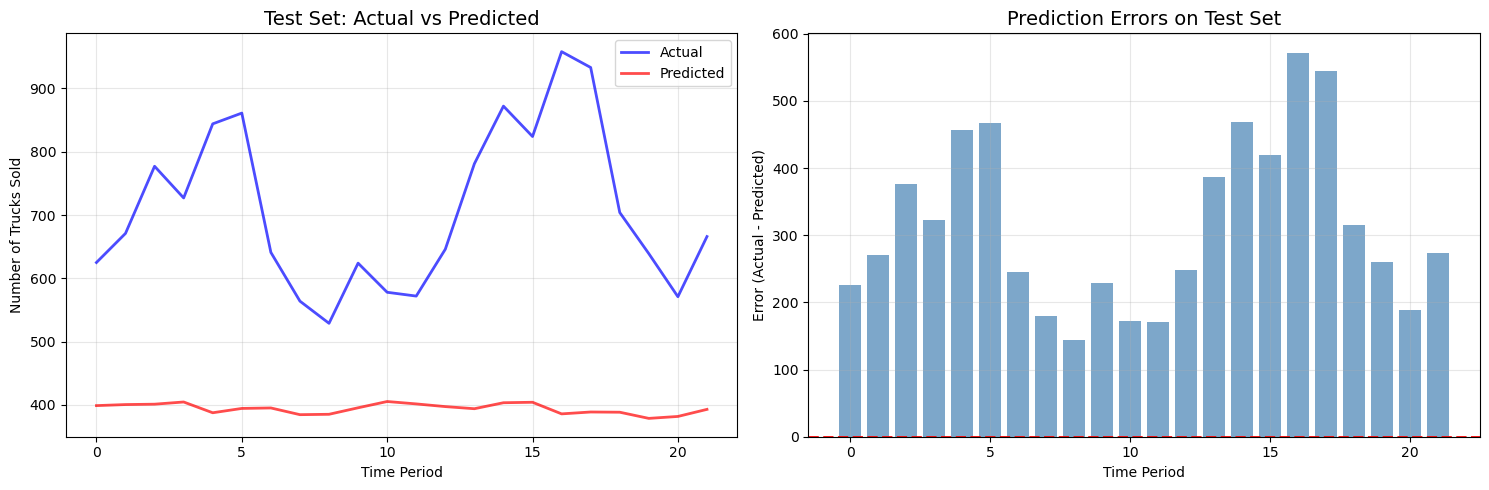

Средняя ошибка: 315.19 грузовиков
Стандартное отклонение ошибки: 124.52 грузовиков
Максимальная ошибка: 572.04 грузовиков


In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.plot(y_test_orig, label='Actual', linewidth=2, alpha=0.7, color='blue')
plt.plot(test_pred, label='Predicted', linewidth=2, alpha=0.7, color='red')
plt.title('Test Set: Actual vs Predicted', fontsize=14)
plt.xlabel('Time Period')
plt.ylabel('Number of Trucks Sold')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
errors = y_test_orig - test_pred
plt.bar(range(len(errors)), errors.flatten(), alpha=0.7, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Prediction Errors on Test Set', fontsize=14)
plt.xlabel('Time Period')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Средняя ошибка: {errors.mean():.2f} грузовиков")
print(f"Стандартное отклонение ошибки: {errors.std():.2f} грузовиков")
print(f"Максимальная ошибка: {np.max(np.abs(errors)):.2f} грузовиков")

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, LSTM, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [50]:
X_train_tf = X_scaled[:split]
X_test_tf = X_scaled[split:]
y_train_tf = y_scaled[:split]
y_test_tf = y_scaled[split:]


X_train_tf = X_train_tf.reshape(X_train_tf.shape[0], 1, X_train_tf.shape[1])
X_test_tf = X_test_tf.reshape(X_test_tf.shape[0], 1, X_test_tf.shape[1])

In [51]:
model_rnn = Sequential([
    SimpleRNN(units=32, activation='tanh', return_sequences=False, 
              input_shape=(1, X_train_tf.shape[2])),
    Dense(1)
])

model_rnn.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
model_rnn.summary()

C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)


history_rnn = model_rnn.fit(
    X_train_tf, y_train_tf,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 396ms/step - loss: 0.1171 - mae: 0.2620 - val_loss: 0.0873 - val_mae: 0.2257
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1005 - mae: 0.2644 - val_loss: 0.0185 - val_mae: 0.1245
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0158 - mae: 0.0988 - val_loss: 0.1286 - val_mae: 0.3387
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0394 - mae: 0.1715 - val_loss: 0.0523 - val_mae: 0.2006
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0130 - mae: 0.0925 - val_loss: 0.0335 - val_mae: 0.1445
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0172 - mae: 0.1076 - val_loss: 0.0579 - val_mae: 0.2100
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0153 - mae: 0.0963 - val_loss: 0.0155 - val_mae: 0.1018
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0091 - mae: 0.0769 - val_loss: 0.0228 - val_mae: 0.1290
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0111 - ma

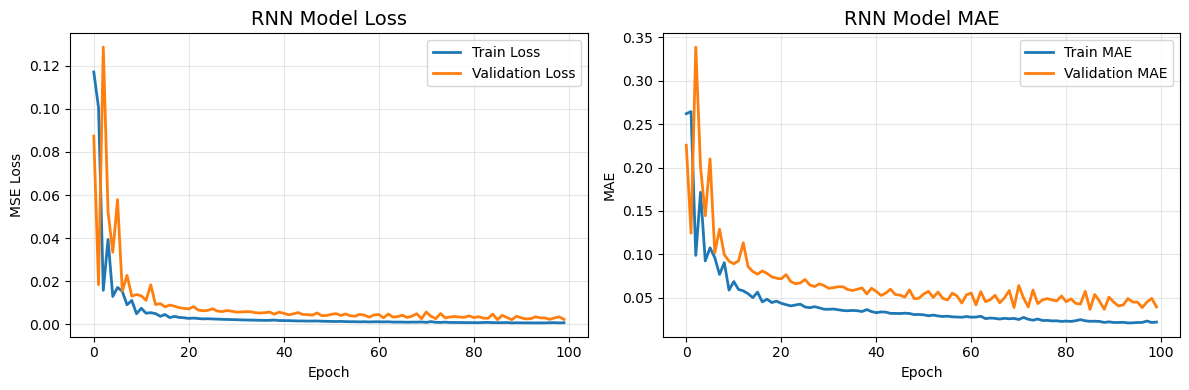

Final train loss: 0.000808
Final validation loss: 0.002383


In [54]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_rnn.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('RNN Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history_rnn.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('RNN Model MAE', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final train loss: {history_rnn.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history_rnn.history['val_loss'][-1]:.6f}")

In [57]:
train_pred_simple_rnn = model_rnn.predict(X_train_tf, verbose=0)
test_pred_simple_rnn = model_rnn.predict(X_test_tf, verbose=0)
train_pred_simple_rnn_orig = scaler_y.inverse_transform(train_pred_simple_rnn)
test_pred_simple_rnn_orig = scaler_y.inverse_transform(test_pred_simple_rnn)
print(f"Train pred shape: {train_pred_simple_rnn_orig.shape}")
print(f"Test pred shape: {test_pred_simple_rnn_orig.shape}")

Train pred shape: (110, 1)
Test pred shape: (22, 1)


In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_simple_train = mean_absolute_error(y_train_orig, train_pred_simple_rnn_orig)
rmse_simple_train = np.sqrt(mean_squared_error(y_train_orig, train_pred_simple_rnn_orig))
r2_simple_train = r2_score(y_train_orig, train_pred_simple_rnn_orig)

mae_simple_test = mean_absolute_error(y_test_orig, test_pred_simple_rnn_orig)
rmse_simple_test = np.sqrt(mean_squared_error(y_test_orig, test_pred_simple_rnn_orig))
r2_simple_test = r2_score(y_test_orig, test_pred_simple_rnn_orig)


print("Tren")
print(f"MAE:  {mae_simple_train:.2f} грузовиков")
print(f"RMSE: {rmse_simple_train:.2f} грузовиков")
print(f"R²:   {r2_simple_train:.4f}")
print("Test")
print(f"MAE:  {mae_simple_test:.2f} грузовиков")
print(f"RMSE: {rmse_simple_test:.2f} грузовиков")
print(f"R²:   {r2_simple_test:.4f}")


Tren
MAE:  20.74 грузовиков
RMSE: 26.77 грузовиков
R²:   0.9648
Test
MAE:  57.69 грузовиков
RMSE: 71.40 грузовиков
R²:   0.6730


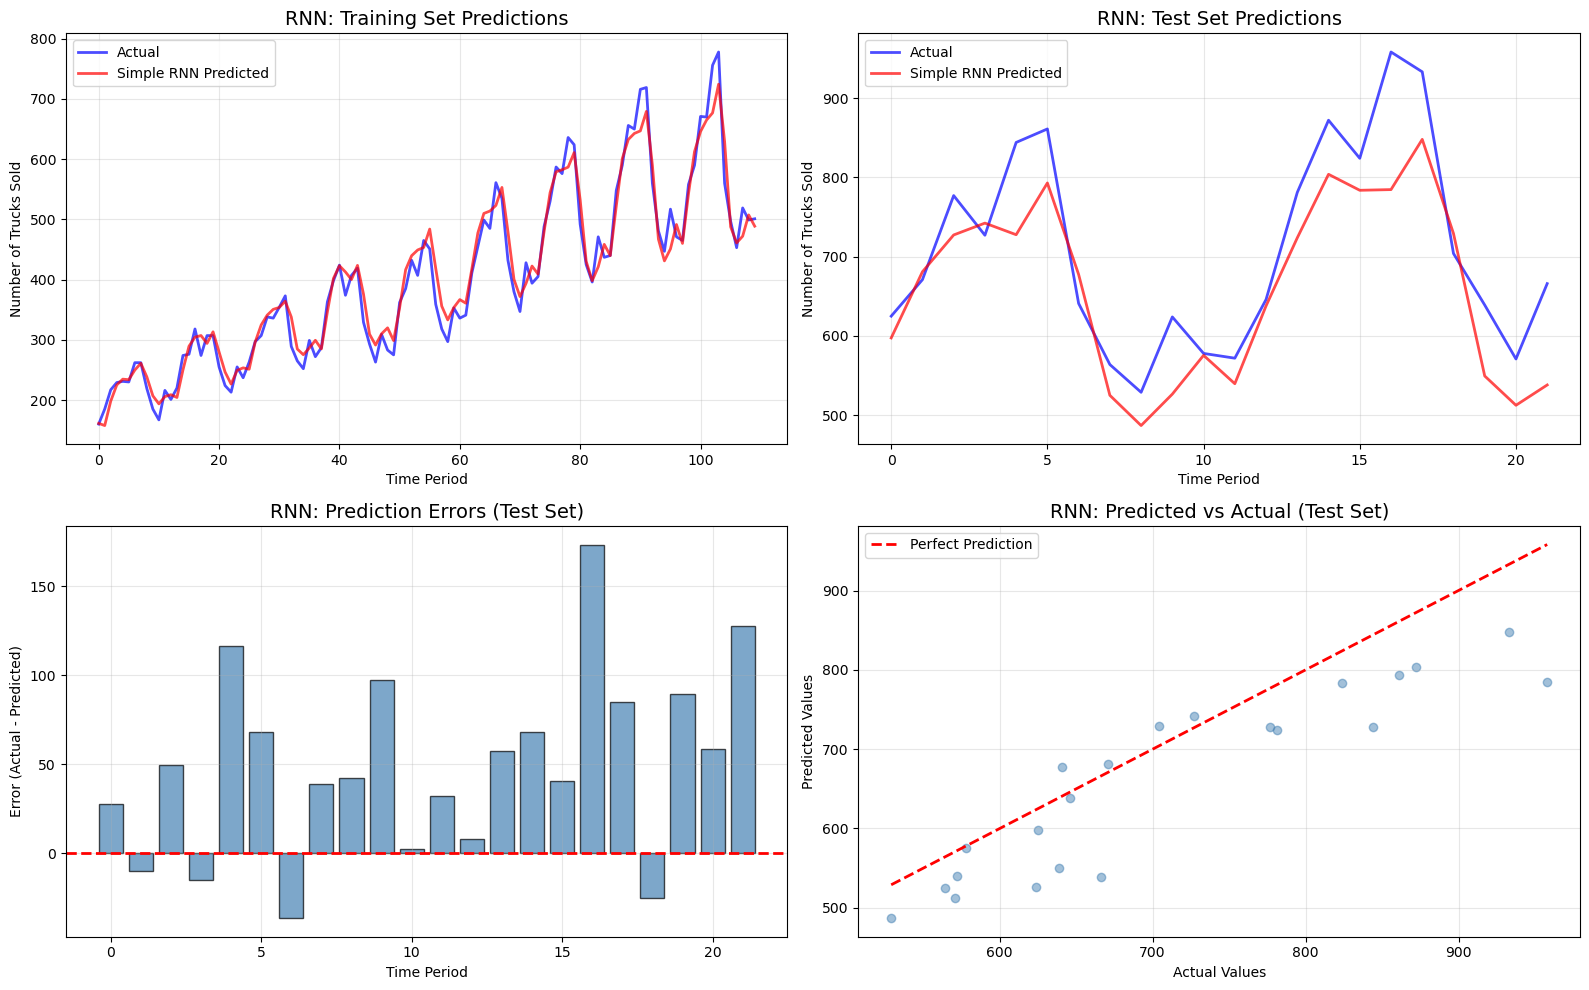

Средняя ошибка: 49.78 грузовиков
Медианная ошибка: 45.79 грузовиков
Стандартное отклонение: 51.18 грузовиков
Максимальная ошибка: 173.46 грузовиков
Минимальная ошибка: 2.40 грузовиков


In [61]:
plt.figure(figsize=(16, 10))


plt.subplot(2, 2, 1)
plt.plot(y_train_orig, label='Actual', linewidth=2, alpha=0.7, color='blue')
plt.plot(train_pred_simple_rnn_orig, label='Simple RNN Predicted', linewidth=2, alpha=0.7, color='red')
plt.title('RNN: Training Set Predictions', fontsize=14)
plt.xlabel('Time Period')
plt.ylabel('Number of Trucks Sold')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(2, 2, 2)
plt.plot(y_test_orig, label='Actual', linewidth=2, alpha=0.7, color='blue')
plt.plot(test_pred_simple_rnn_orig, label='Simple RNN Predicted', linewidth=2, alpha=0.7, color='red')
plt.title('RNN: Test Set Predictions', fontsize=14)
plt.xlabel('Time Period')
plt.ylabel('Number of Trucks Sold')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(2, 2, 3)
errors_simple = y_test_orig - test_pred_simple_rnn_orig
plt.bar(range(len(errors_simple)), errors_simple.flatten(), alpha=0.7, color='steelblue', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('RNN: Prediction Errors (Test Set)', fontsize=14)
plt.xlabel('Time Period')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.3)


plt.subplot(2, 2, 4)
plt.scatter(y_test_orig, test_pred_simple_rnn_orig, alpha=0.5, color='steelblue')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('RNN: Predicted vs Actual (Test Set)', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Средняя ошибка: {errors_simple.mean():.2f} грузовиков")
print(f"Медианная ошибка: {np.median(errors_simple):.2f} грузовиков")
print(f"Стандартное отклонение: {errors_simple.std():.2f} грузовиков")
print(f"Максимальная ошибка: {np.max(np.abs(errors_simple)):.2f} грузовиков")
print(f"Минимальная ошибка: {np.min(np.abs(errors_simple)):.2f} грузовиков")